In [17]:
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import sys
import os

# 現在のディレクトリ(notebooks)の「一つ上(project)」をパスに追加
sys.path.append(os.path.abspath(".."))
from libs import fit_model as fm
from libs import my_statics

save_folder = "../figures/deltatheta"
os.makedirs(save_folder, exist_ok=True)

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

interval = 10

def getdf(dir_path, interval=10):
    df_list = []

    file_list = glob.glob(os.path.join(dir_path, "*.csv"))
    for file_path in file_list:
        file = pd.read_csv(file_path)
        df_list.append(file)

    df_concat = pd.concat(df_list, ignore_index=True)

    only_MT = df_concat[df_concat['TID'] == 1]['Δα [deg]'].to_numpy()

    plots = only_MT[~np.isnan(only_MT)]

    return plots

MC00_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240827/cargo_before_after_MT1uM_MC00')
MC00_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC00')
MC00_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240828/cargo_before')
MC00_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241129/cargo_before_after_MT1uM_MC00') 

MC00 = [MC00_1, MC00_2, MC00_3, MC00_4]
MC00 = np.concatenate(MC00) * (2*np.pi/360)  # deg -> rad

MC03_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_after_MT1uM_MC03')
MC03_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_MT083uM_MC03_1')
MC03_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC03')
MC03_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241127/cargo_before_after_MT1uM_MC03')

MC03 = [MC03_1, MC03_2, MC03_3, MC03_4]
MC03 = np.concatenate(MC03) * (2*np.pi/360)  # deg -> rad

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14382/671487570.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax.set(xlabel='$\Delta \\theta$ [rad]',
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14382/671487570.py:31: RuntimeWarning: invalid value encountered in sqrt
  print(f"mu:{np.sqrt(popt00[0]):.4f}, std: {np.sqrt(popt00[1]):.4f} rad/s")


MC00
mu:nan, std: 0.4981 rad/s


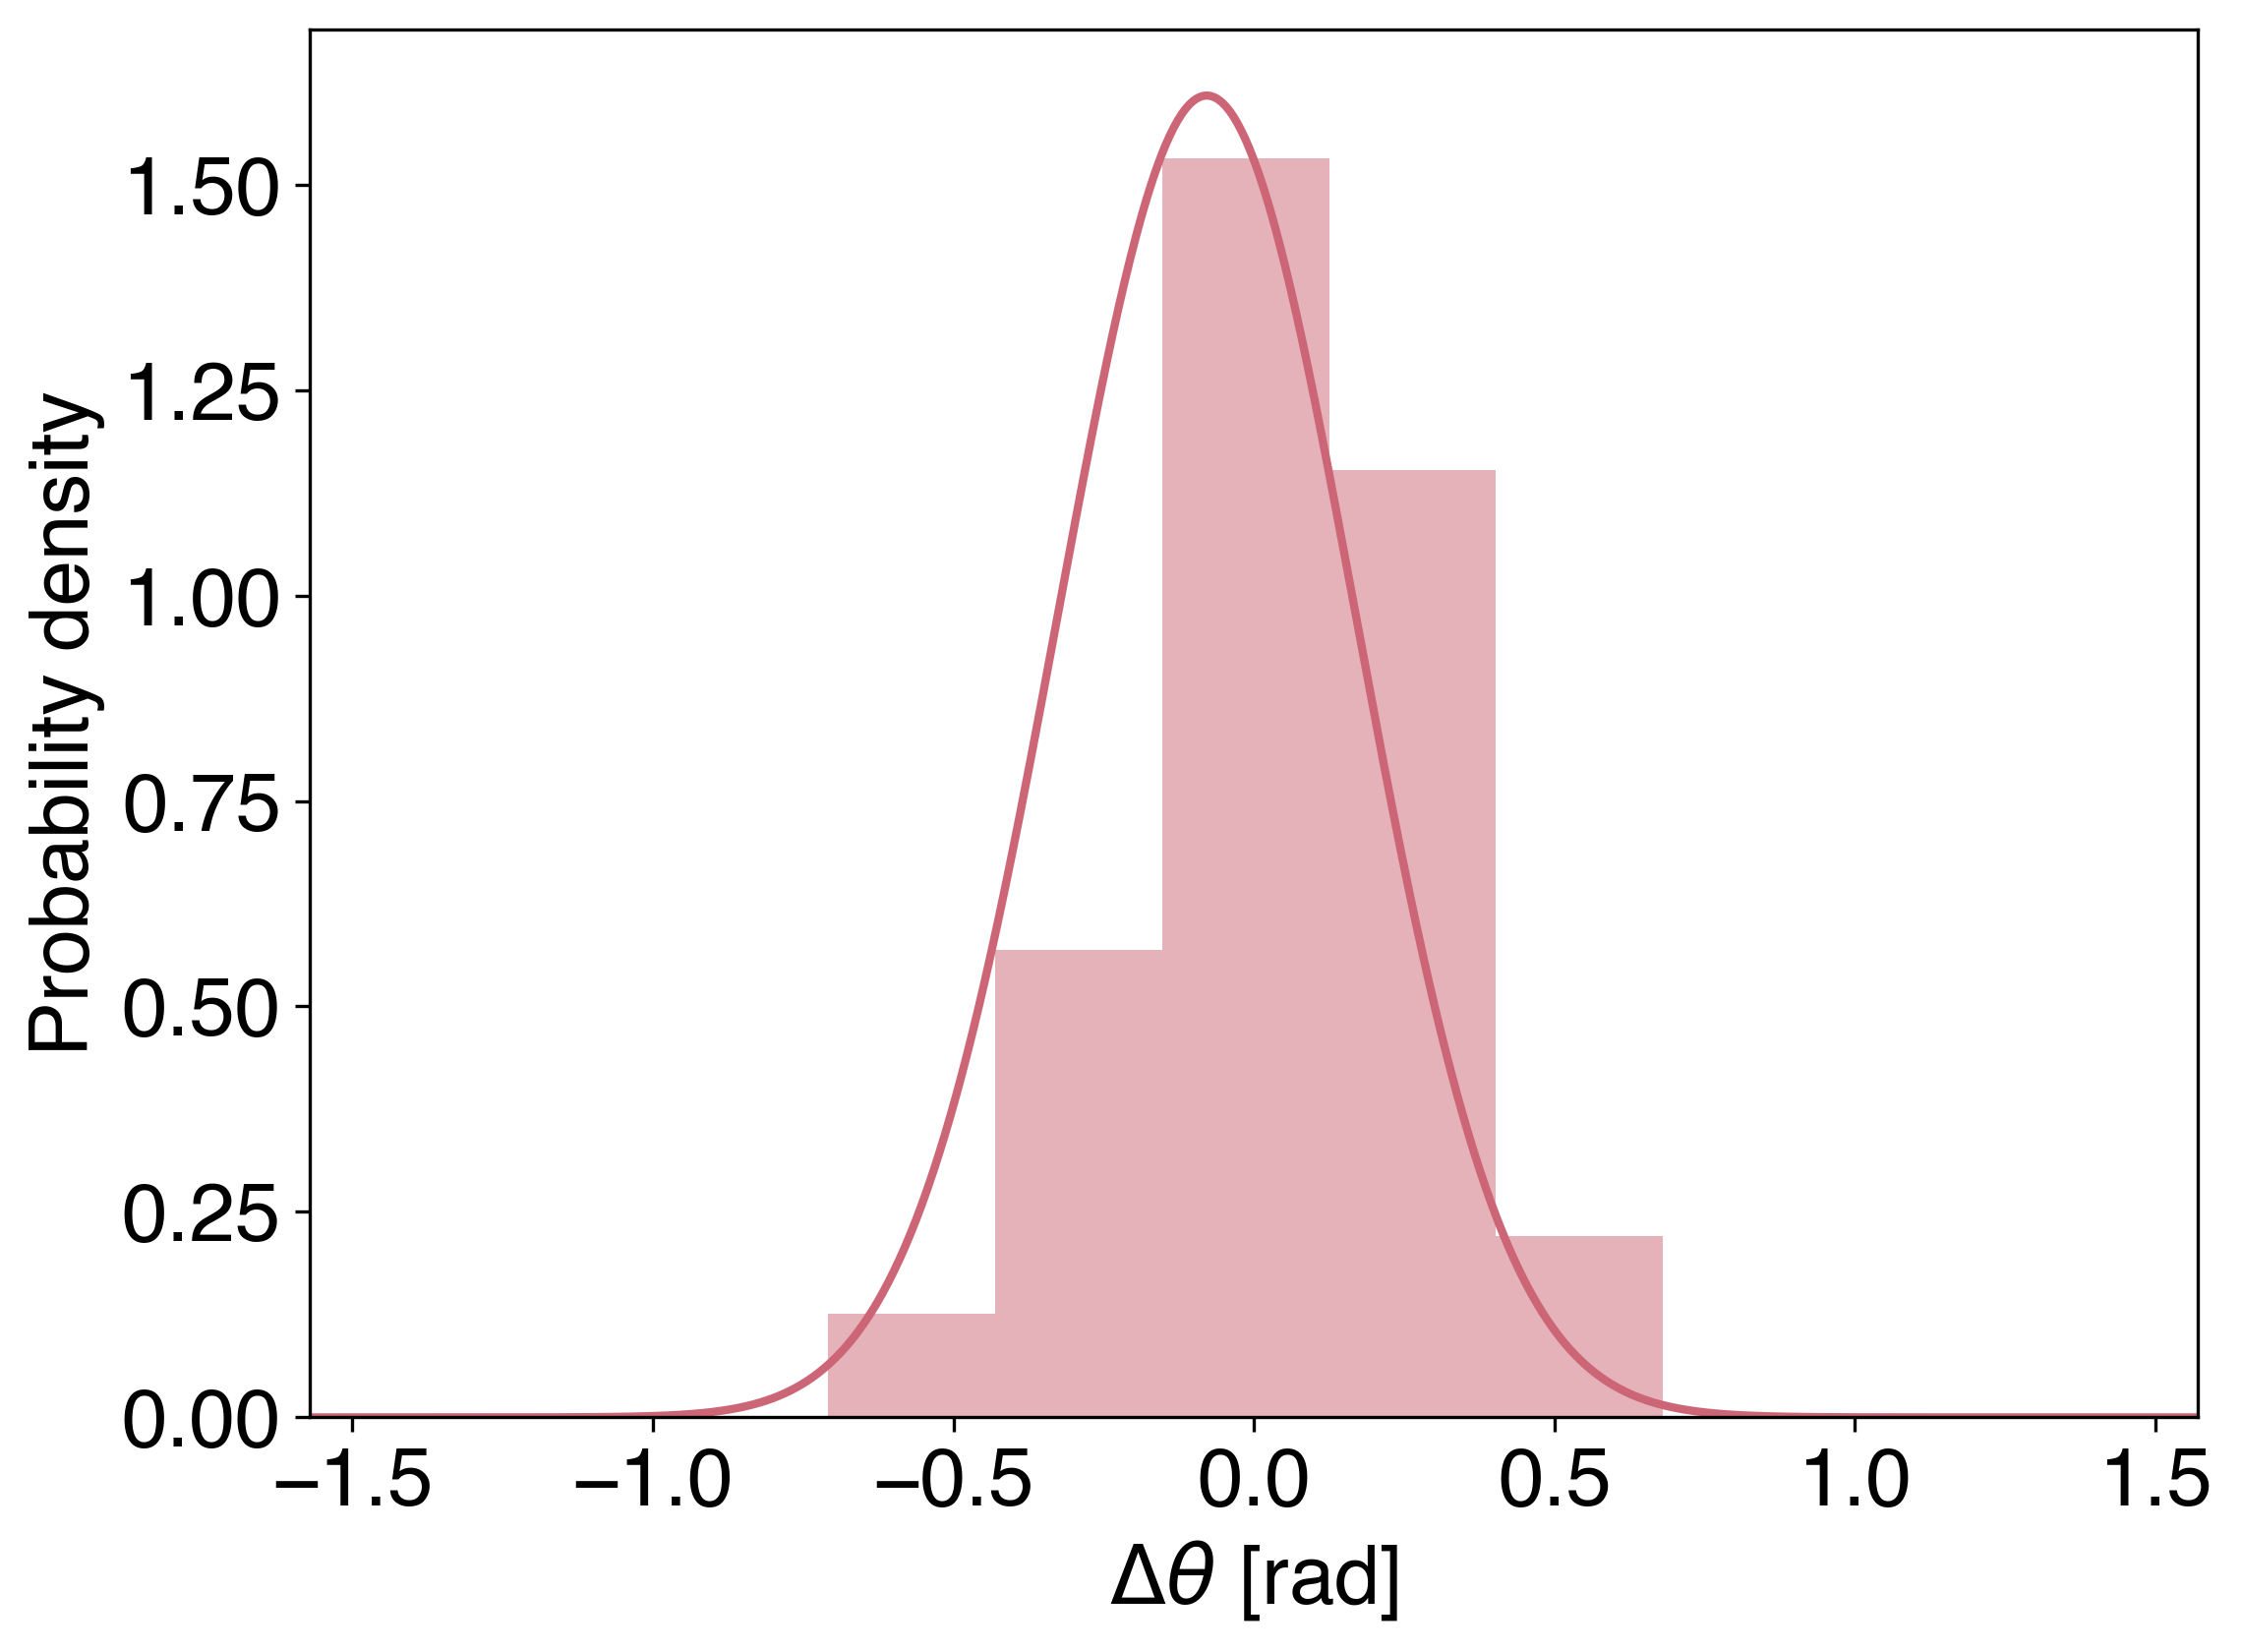

In [26]:
def get_bin(data1, data2, bins):
    bins1 = np.histogram_bin_edges(data1, bins=bins)
    bins2 = np.histogram_bin_edges(data2, bins=bins)
    if len(bins1) > len(bins2):
        return bins1
    else:
        return bins2

bins = get_bin(MC00, MC03, bins='sturges')

def hist_fit(data, bins, ax=None, color = None, label=None):

    hist, bin_edges = np.histogram(data, bins=bins, density=True)
    popt, pcov = curve_fit(fm.gaussian, bin_edges[:-1], hist)

    if ax is not None:
        ax.hist(data, bins, density=True, alpha=0.5, color=color)
        ax.plot(np.linspace(-np.pi/2, np.pi/2, 1000),  fm.gaussian(np.linspace(-np.pi/2, np.pi/2, 1000), *popt), color=color, label=label)

    return popt, pcov

fig, ax = plt.subplots()

ax.set(xlabel='$\Delta \\theta$ [rad]',
    ylabel='Probability density',
    xlim=(-np.pi/2, np.pi/2))

popt00, pcov00 = hist_fit(MC00, bins, ax=ax, color=style_colors[0], label='MC00')

print("MC00")
print(f"mu:{np.sqrt(popt00[0]):.4f}, std: {np.sqrt(popt00[1]):.4f} rad/s")

fig.savefig(f"{save_folder}/MC00.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/MC00.pdf", bbox_inches='tight')

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14382/2618913963.py:3: SyntaxWarning: invalid escape sequence '\D'
  ax.set(xlabel='$\Delta \\theta$ [rad]',
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14382/2618913963.py:10: RuntimeWarning: invalid value encountered in sqrt
  print(f"mu:{np.sqrt(popt03[0]):.4f}, std: {np.sqrt(popt03[1]):.4f} rad/s")


MC03
mu:nan, std: 0.4902 rad/s


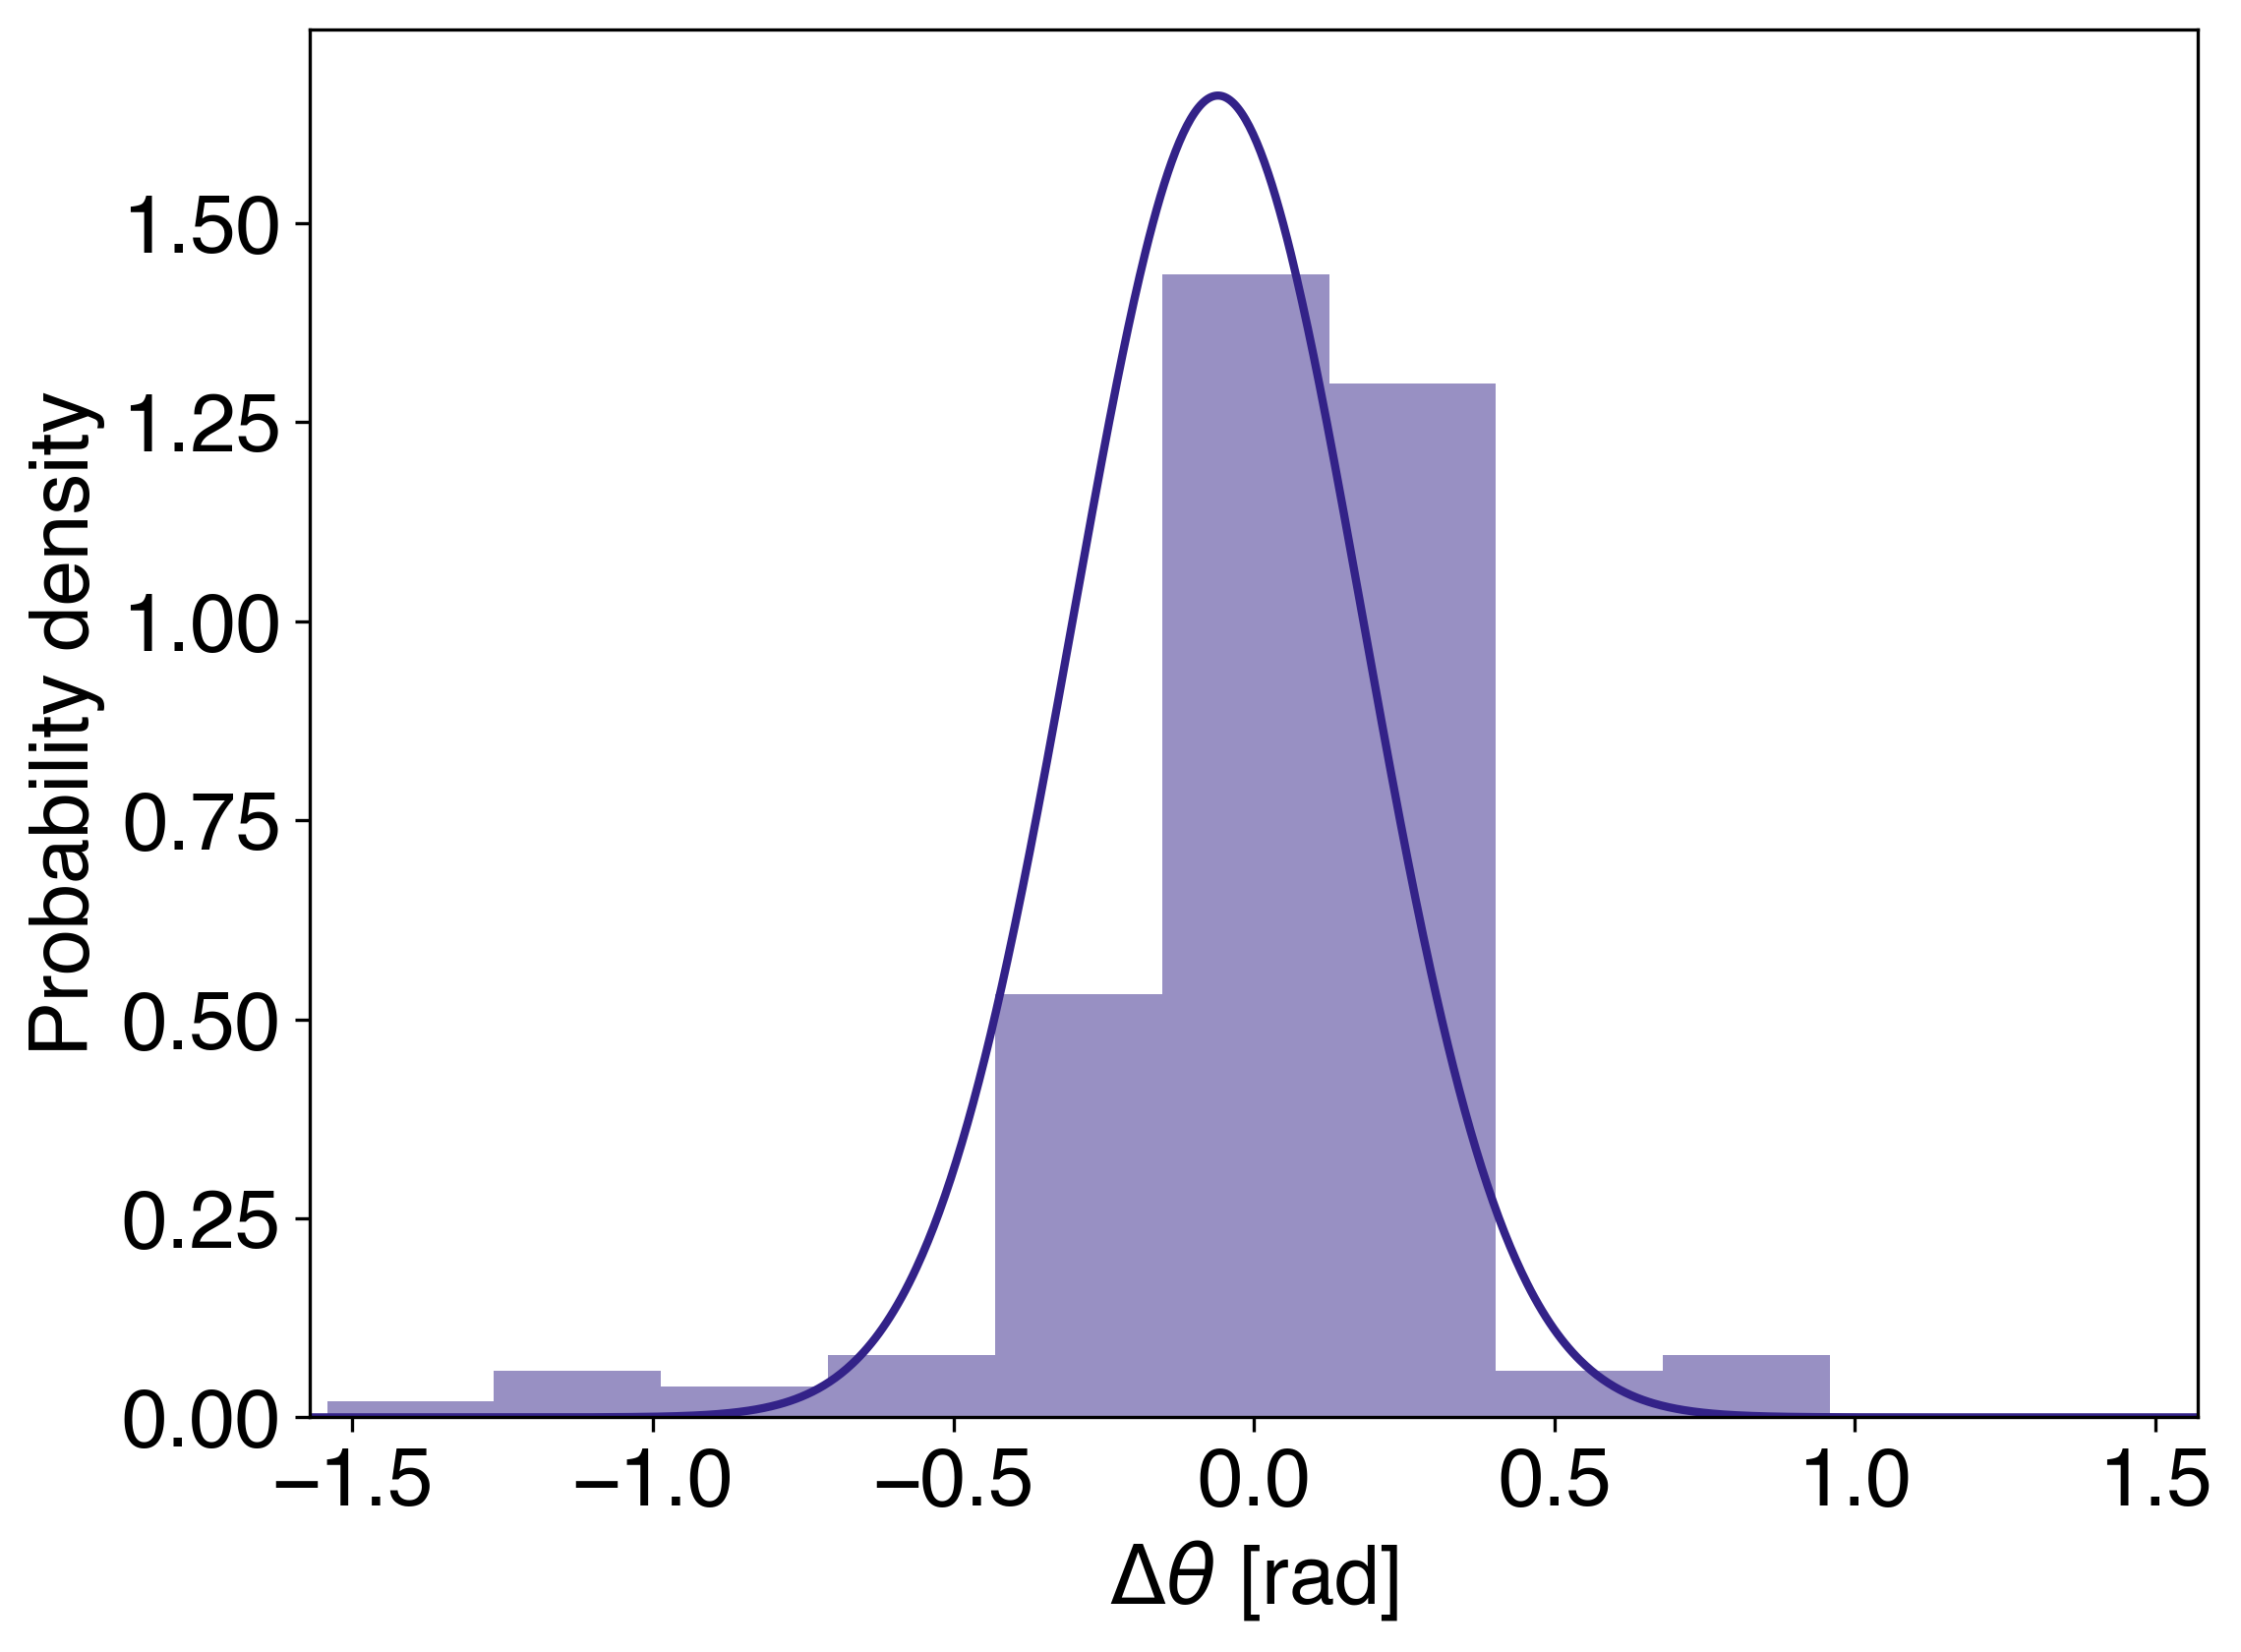

In [25]:
fig, ax = plt.subplots()

ax.set(xlabel='$\Delta \\theta$ [rad]',
    ylabel='Probability density',
    xlim=(-np.pi/2, np.pi/2))

popt03, pcov03 = hist_fit(MC03, bins, ax=ax, color=style_colors[1], label='MC03')

print("MC03")
print(f"mu:{np.sqrt(popt03[0]):.4f}, std: {np.sqrt(popt03[1]):.4f} rad/s")
fig.savefig(f"{save_folder}/MC03.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/MC03.pdf", bbox_inches='tight')

T-statistic: 0.7613, P-value: 0.4469


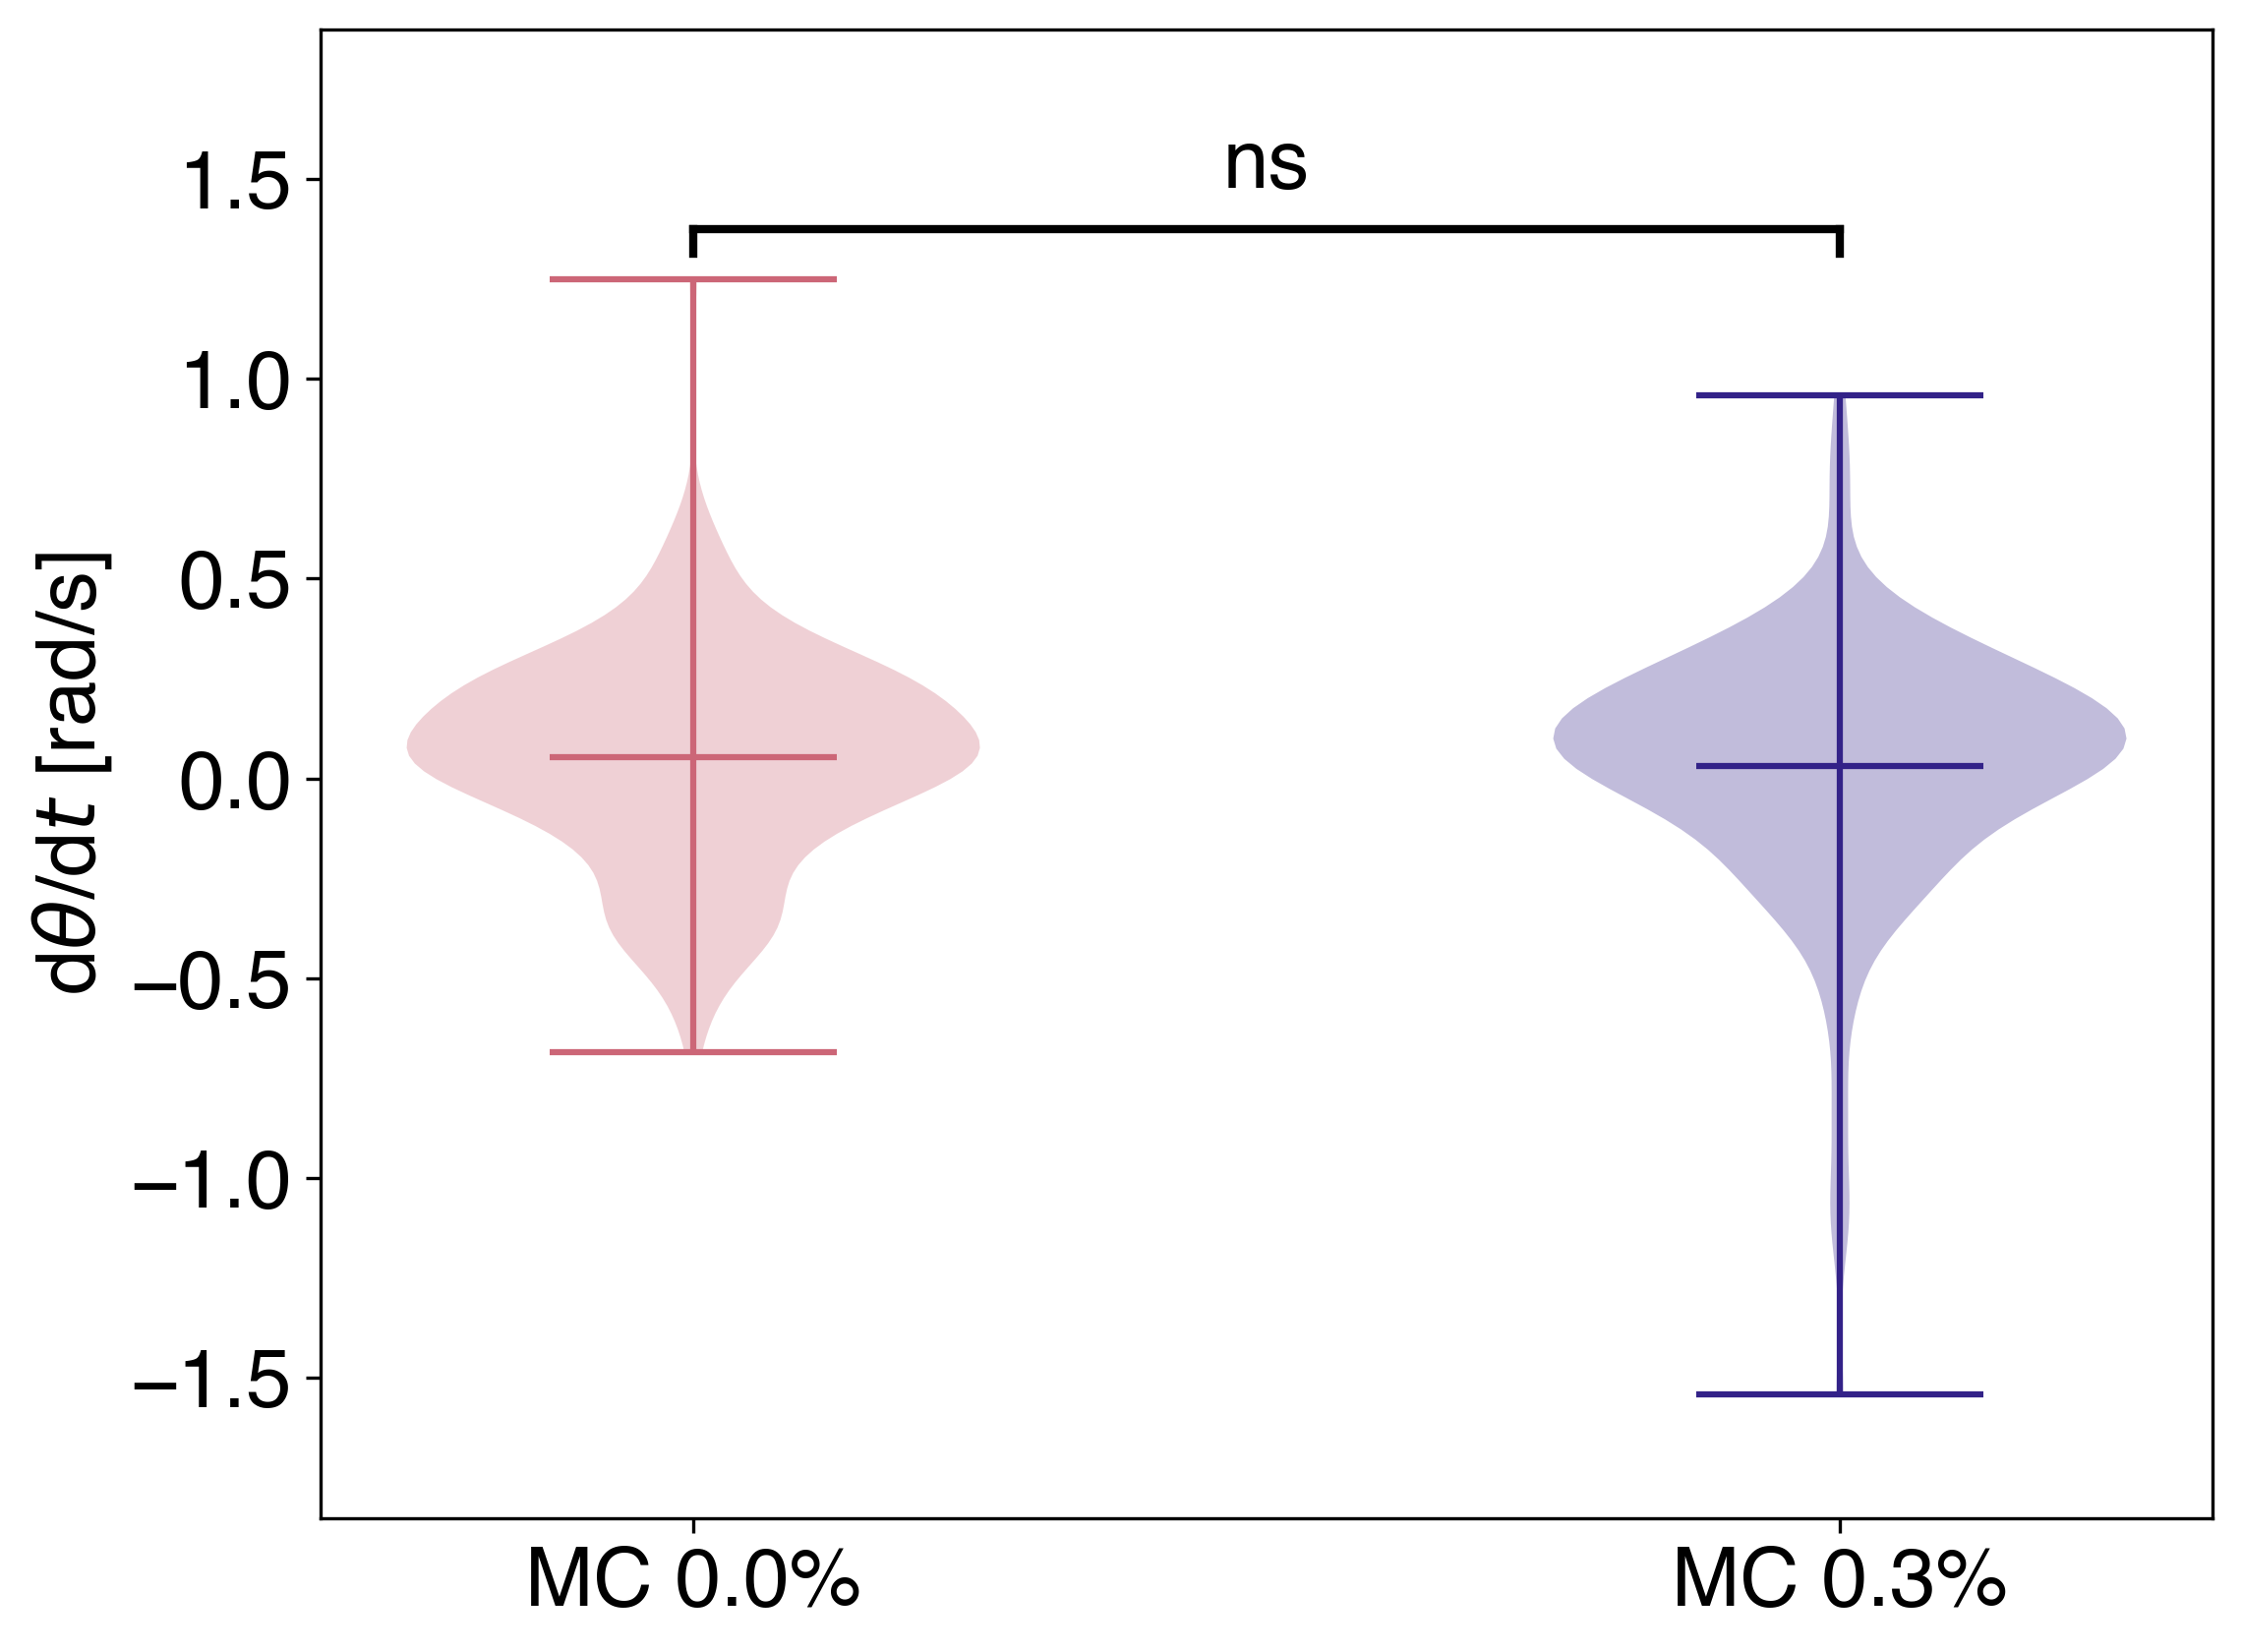

In [20]:
# t検定を実行

statics, p_value, sig_text = my_statics.ttest(MC00, MC03, equal_var=True)
print(f"T-statistic: {statics:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots()
my_statics.violin(MC00, ax, positions=0, color=style_colors[0])
my_statics.violin(MC03, ax, positions=1, color=style_colors[1])

ax.set_xticks([0, 1], ['MC 0.0%', 'MC 0.3%'])
ax.set_ylabel('d$\\theta$/d$t$ [rad/s]')

ax.text(0.5, max(np.max(MC00), np.max(MC03))*1.15, sig_text, ha='center', va='bottom')
ax.plot([0, 1], [max(np.max(MC00), np.max(MC03))*1.1]*2, color='black')
ax.plot([0, 0], [max(np.max(MC00), np.max(MC03))*1.05, max(np.max(MC00), np.max(MC03))*1.1], color='black')
ax.plot([1, 1], [max(np.max(MC00), np.max(MC03))*1.05, max(np.max(MC00), np.max(MC03))*1.1], color='black')

ax.set(ylim = (min(np.min(MC00), np.min(MC03))*1.2, max(np.max(MC00), np.max(MC03))*1.5))
fig.savefig(f"{save_folder}/violin.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/violin.pdf", bbox_inches='tight')

[Text(0.5, 0, '$\\Delta \\theta$'),
 Text(0, 0.5, 'Probability density'),
 (-1.5707963267948966, 1.5707963267948966)]

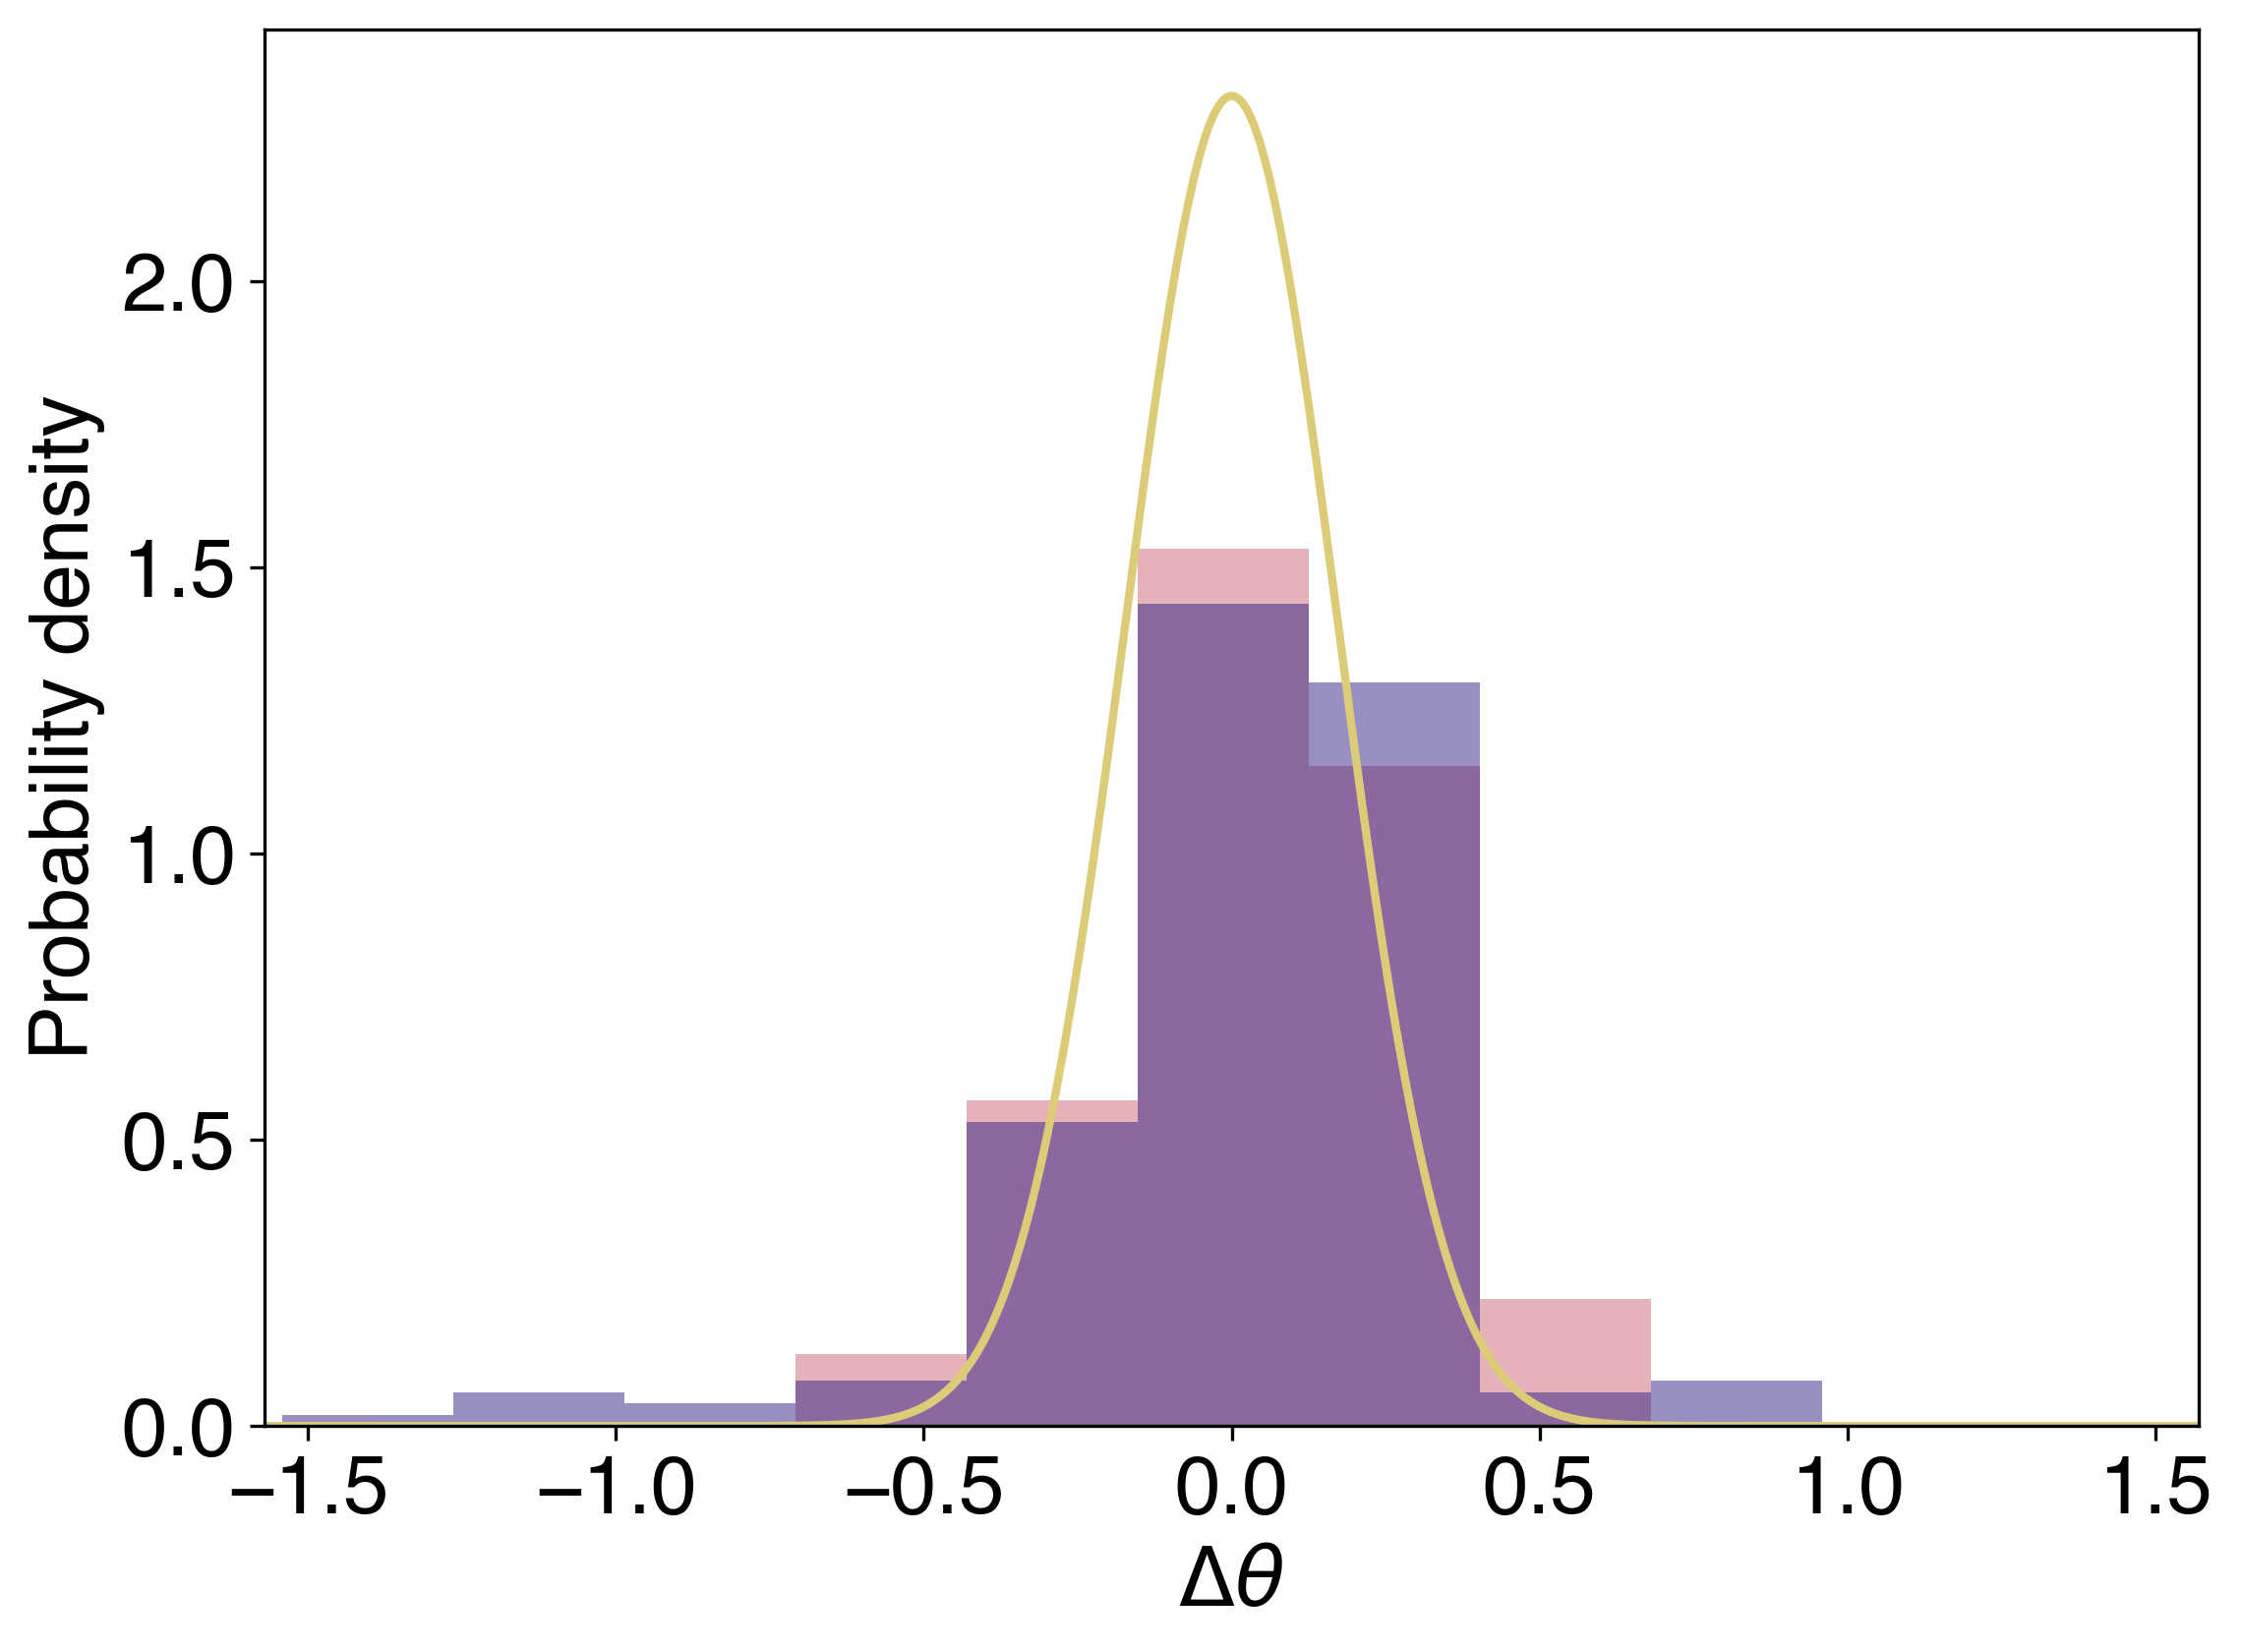

In [ ]:
from scipy.stats import norm

noise_std = 0.49

R=0.59
v=0.5
dt = 1
tau = R/v

Dr_exp = 0.0125
Dr = tau * Dr_exp

x = np.linspace(-np.pi/2, np.pi/2, 1000)
sigma = np.sqrt(2*Dr*dt)

noise_dist = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

pdf = norm.pdf(x, loc=0, scale=sigma)

fig, ax = plt.subplots()

bins = get_bin(MC00, MC03, bins='sturges')

ax.hist(MC00, bins, density=True, alpha=0.5)
ax.hist(MC03, bins, density=True, alpha=0.5)

ax.plot(x, pdf)

ax.set(xlabel='$\\Delta \\theta$ [rad]',
    ylabel='Probability density',
    xlim=(-np.pi/2, np.pi/2))

fig.savefig(f"{save_folder}/theory.png", bbox_inches='tight')
fig.savefig(f"{save_folder}/theory.pdf", bbox_inches='tight')